In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,root_mean_squared_error

In [4]:
df = pd.read_csv("Salary_dataset.csv")

In [5]:
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [6]:
df.columns

Index(['Unnamed: 0', 'YearsExperience', 'Salary'], dtype='str')

In [7]:
df=df.drop(columns='Unnamed: 0')

In [8]:
df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


{'whiskers': [<matplotlib.lines.Line2D at 0x70f6bfe5cfe0>,
 'caps': [<matplotlib.lines.Line2D at 0x70f6bfe5e0f0>,
 'boxes': [<matplotlib.lines.Line2D at 0x70f6bffd0cb0>],
 'medians': [<matplotlib.lines.Line2D at 0x70f6bfe5da00>],
 'fliers': [<matplotlib.lines.Line2D at 0x70f6bfe5d550>],
 'means': []}

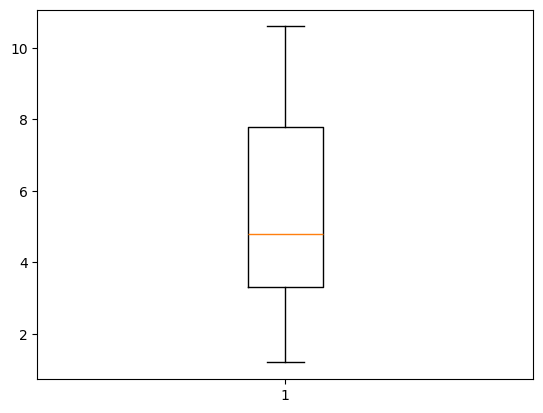

In [10]:
plt.boxplot(df['YearsExperience'])

{'whiskers': [<matplotlib.lines.Line2D at 0x70f6bfe775f0>,
 'caps': [<matplotlib.lines.Line2D at 0x70f6bfe77bc0>,
 'boxes': [<matplotlib.lines.Line2D at 0x70f6bfe77440>],
 'medians': [<matplotlib.lines.Line2D at 0x70f6bfe781d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x70f6bfe784a0>],
 'means': []}

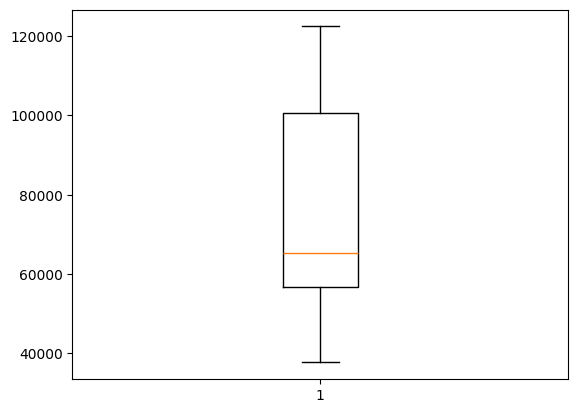

In [11]:
plt.boxplot(df['Salary'])

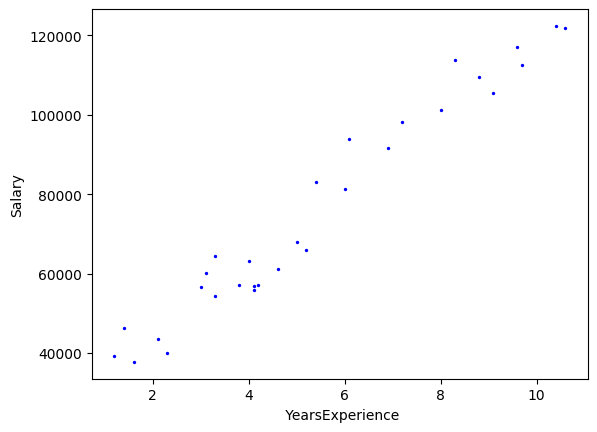

In [14]:
plt.scatter(x=df['YearsExperience'],y=df['Salary'],s=2,color='blue')
plt.xlabel(" YearsExperience")
plt.ylabel("Salary")
plt.show()

In [15]:
X=df.drop(columns=['Salary'])
y=df['Salary']

In [17]:
X.head()

,YearsExperience
0,1.2
1,1.4
2,1.6
3,2.1
4,2.3


In [19]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [18]:
model=LinearRegression()

In [20]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
y_pred=model.predict(x_test)

/home/mdsaif/Desktop/Introduction_ML_4125/ML/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


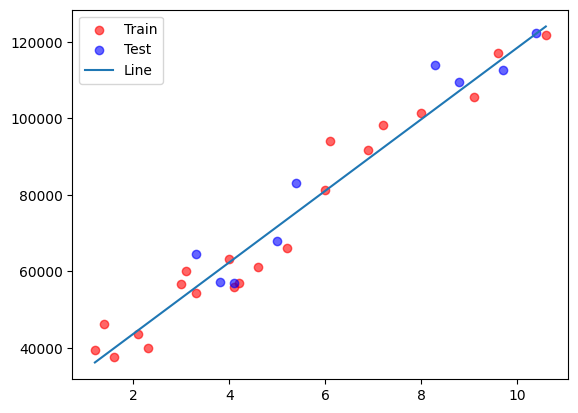

In [23]:
x_end=[X.min(),X.max()]
plt.scatter(x=x_train,y=y_train,color='red',alpha=0.6,label='Train')
plt.scatter(x=x_test,y=y_test,color='b',alpha=0.6,label='Test')
plt.plot(x_end,model.predict(x_end),label='Line')
plt.legend()
plt.show()

In [24]:
print(f"R2 = {r2_score(y_pred=y_pred, y_true=y_test)}")
print(f"RMSE = {root_mean_squared_error(y_pred=y_pred, y_true=y_test)}")

R2 = 0.9414466227178215
RMSE = 6146.9230079945755
